# AI RAG with LangGraph

In [1]:
import cassio
import os

# Connection to the ASTRA database
ASTRA_DB_APPLICATION_TOKEN = os.getenv("ASTRA_DB_APPLICATION_TOKEN")
ASTRA_DB_ID = os.getenv("ASTRA_DB_ID")
ASTRA_DB_KEYSPACE = os.getenv("ASTRA_DB_KEYSPACE")

cassio.init(
    token=ASTRA_DB_APPLICATION_TOKEN,
    database_id=ASTRA_DB_ID,
    keyspace=ASTRA_DB_KEYSPACE
)


In [2]:
# Build Index
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader

# Doc to Index
urls = [
    "https://groq.com/",
    "https://www.langchain.com/",
    "https://www.langchain.com/langsmith"
]

# load
docs = [WebBaseLoader(url).load() for url in urls]
doc_list = [item for sublist in docs for item in sublist]
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size=500, chunk_overlap=0)
docs_split = text_splitter.split_documents(doc_list)

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [3]:
from langchain_huggingface import HuggingFaceEmbeddings
from dotenv import load_dotenv
load_dotenv()

embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

/home/vibhav911/Documents/skills/DataScience/Lang-chain/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/vibhav911/Documents/skills/DataScience/Lang-chain/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


In [4]:
from langchain.vectorstores.cassandra import  Cassandra
astra_vectorstore = Cassandra(embedding=embeddings, table_name="LangGraphTest",
                              session=None, 
                              keyspace=ASTRA_DB_KEYSPACE)

In [5]:
from langchain.indexes.vectorstore import VectorStoreIndexWrapper
astra_vectorstore.add_documents(docs_split)
astra_vectorstore_index = VectorStoreIndexWrapper(vectorstore=astra_vectorstore)

In [6]:
retriever = astra_vectorstore.as_retriever()

In [7]:
# LangGraph Application
from typing import Literal

from langchain.prompts import ChatPromptTemplate
from langchain.pydantic_v1 import BaseModel, Field

/home/vibhav911/Documents/skills/DataScience/Lang-chain/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3667: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  exec(code_obj, self.user_global_ns, self.user_ns)


In [8]:
# Data Model
class RouteQuery(BaseModel):
    " Route a user Query to the most relevant Data Source "
    datasource: Literal["vectorstore", "wikisearch"] = Field(
        ...,
        description="Choose Vectorstore or wikisearch"
    )

In [9]:
from langchain_groq import ChatGroq
import os

groq_api_key = os.getenv("GROQ_API_KEY")
llm = ChatGroq(groq_api_key=groq_api_key, model="gemma2-9b-it")

In [10]:
structured_llm_router = llm.with_structured_output(RouteQuery)

In [11]:
# Prompt
system = """You are an expert at routing a user question to a vectorstore or wikipedia.
The vectorstore contains documents related to agents, prompt engineering, and adversarial attacks.
Use the vectorstore for questions on these topics. Otherwise, use wiki-search."""
route_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question}"),
    ]
)

question_router = route_prompt | structured_llm_router
print(
    question_router.invoke(
        {"question": "who is Sharukh Khan?"}
    )
)
print(question_router.invoke({"question": "What are the types of agent memory?"}))

datasource='wikisearch'
datasource='vectorstore'


In [12]:
### Working With Tools
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun

## Arxiv and wikipedia Tools
arxiv_wrapper=ArxivAPIWrapper(top_k_results=1, doc_content_chars_max=200)
arxiv=ArxivQueryRun(api_wrapper=arxiv_wrapper)

api_wrapper=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=200)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper)

In [13]:
## Graph

from typing import List

from typing_extensions import TypedDict


class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        documents: list of documents
    """

    question: str
    generation: str
    documents: List[str]

In [14]:
from langchain.schema import Document


def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state["question"]

    # Retrieval
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}

In [15]:
def wiki_search(state):
    """
    wiki search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """

    print("---wikipedia---")
    print("---HELLO--")
    question = state["question"]
    print(question)

    # Wiki search
    docs = wiki.invoke({"query": question})
    #print(docs["summary"])
    wiki_results = docs
    wiki_results = Document(page_content=wiki_results)

    return {"documents": wiki_results, "question": question}

In [16]:
### Edges ###


def route_question(state):
    """
    Route question to wiki search or RAG.

    Args:
        state (dict): The current graph state

    Returns:
        str: Next node to call
    """

    print("---ROUTE QUESTION---")
    question = state["question"]
    source = question_router.invoke({"question": question})
    if source.datasource == "wiki_search":
        print("---ROUTE QUESTION TO Wiki SEARCH---")
        return "wiki_search"
    elif source.datasource == "vectorstore":
        print("---ROUTE QUESTION TO RAG---")
        return "vectorstore"

In [18]:
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(GraphState)
# Define the nodes
workflow.add_node("wiki_search", wiki_search)  # web search
workflow.add_node("retrieve", retrieve)  # retrieve

# Build graph
workflow.add_conditional_edges(
    START,
    route_question,
    {
        "wiki_search": "wiki_search",
        "vectorstore": "retrieve",
    },
)
# workflow.add_edge(START, route_question)
# workflow.add_conditional_edges(
#     route_question,
#     {
#         "wiki_search": "wiki_search",
#         "vectorstore": "retrieve",
#     },
# )
workflow.add_edge( "retrieve", END)
workflow.add_edge( "wiki_search", END)
# Compile
app = workflow.compile()

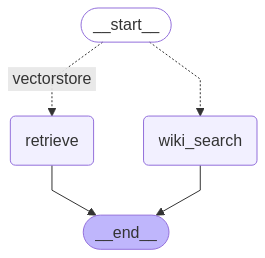

In [19]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
from pprint import pprint

# Run
inputs = {
    "question": "What is agent?"
}
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        # pprint.pprint(value["keys"], indent=2, width=80, depth=None)
    pprint("\n---\n")

# Final generation
pprint(value['documents'][0].dict()['metadata']['description'])

---ROUTE QUESTION---
---ROUTE QUESTION TO RAG---
---RETRIEVE---
"Node 'retrieve':"
'\n---\n'
('LangChain’s suite of products supports developers along each step of their '
 'development journey.')


/tmp/ipykernel_64896/2686642801.py:16: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  pprint(value['documents'][0].dict()['metadata']['description'])


In [ ]:
from pprint import pprint

# Run
inputs = {
    "question": "Avengers"
}
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        # pprint.pprint(value["keys"], indent=2, width=80, depth=None)
    pprint("\n---\n")

# Final generation
pprint(value['documents'])

---ROUTE QUESTION---
---ROUTE QUESTION TO RAG---
---RETRIEVE---
"Node 'retrieve':"
'\n---\n'
[Document(id='c20306aad6de4545b0023eb4d958d680', metadata={'description': 'The LPU™ Inference Engine by Groq is a hardware and software platform that delivers exceptional compute speed, quality, and energy efficiency. Groq provides cloud and on-prem solutions at scale for AI applications.', 'language': 'en-US', 'source': 'https://groq.com/', 'title': 'Groq is Fast AI Inference'}, page_content='VP & Chief AI Scientist at Meta, Groq Technical Advisor \n\n\n\n\n\n\nREFERENCE | AUGUST 5, 2024\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nGroq in the News \n\n\n\n\n\n \n\n\n\n\n\n\n\n\n\n\n\n\n\nLearn more \n\n\n\n\nAI chip start-up Groq’s value rises to $2.8bn as it takes on Nvidia \n\n\n\n\n \n\n\n\n\n\n\n\n\n\n\n\n\n\nLearn more \n\n\n\n\nAI Chip Startup Groq Gets $2.8 Billion Valuation in New Funding Round \n\n\n\n\n \n\n\n\n\n\n\n\n\n\n\n\n\n\nLearn more \n\n\n\n\nNvidia Challenger Groq Raises at Near-$3B Bil